# Regression Model Evaluation

This notebook focuses on evaluating regression models using error metrics, train/test splits, cross-validation, and residual diagnostics.


## 1. Learning Goals

- Calculate residuals.
- Calculate SSE, MSE, RMSE, MAE, and $R^2$.
- Compare training and test performance.
- Use cross-validation.
- Inspect residuals and actual-vs-predicted plots.
- Understand how evaluation metrics can rank models differently.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


## 2. Actual and Predicted Values


In [2]:
y_true = np.array([50, 60, 70, 80])
y_pred = np.array([48, 63, 68, 76])

results = pd.DataFrame({
    "actual": y_true,
    "predicted": y_pred
})
results["error"] = results["actual"] - results["predicted"]
results["absolute_error"] = results["error"].abs()
results["squared_error"] = results["error"] ** 2

results


,actual,predicted,error,absolute_error,squared_error
0,50,48,2,2,4
1,60,63,-3,3,9
2,70,68,2,2,4
3,80,76,4,4,16


## 3. SSE


In [3]:
sse = np.sum((y_true - y_pred) ** 2)
print("SSE:", sse)


SSE: 33


## 4. MSE, RMSE, and MAE


In [4]:
mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_true, y_pred)

print("MSE:", mse)
print("RMSE:", rmse)
print("MAE:", mae)


MSE: 8.25
RMSE: 2.8722813232690143
MAE: 2.75


## 5. $R^2$


In [5]:
r2 = r2_score(y_true, y_pred)
print("R2:", r2)


R2: 0.9339999999999999


## 6. Train-Test Split


In [6]:
df = pd.DataFrame({
    "study_hours": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    "marks": [40, 44, 49, 53, 60, 64, 69, 73, 78, 84]
})

X = df[["study_hours"]]
y = df["marks"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training observations:", len(X_train))
print("Testing observations:", len(X_test))


Training observations: 8
Testing observations: 2


## 7. Fit and Evaluate the Model


In [7]:
model = LinearRegression()
model.fit(X_train, y_train)

y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

train_mae = mean_absolute_error(y_train, y_train_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)

train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

print("Training MAE:", train_mae)
print("Test MAE:", test_mae)
print("Training RMSE:", train_rmse)
print("Test RMSE:", test_rmse)
print("Training R2:", train_r2)
print("Test R2:", test_r2)


Training MAE: 0.5387931034482767
Test MAE: 0.5
Training RMSE: 0.6499336836196821
Test RMSE: 0.5186761709134947
Training R2: 0.9975758175431653
Test R2: 0.9990691177499187


## 8. Actual vs Predicted Plot


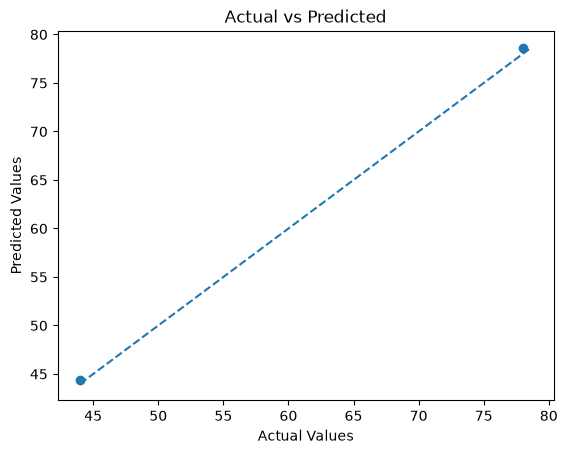

In [8]:
plt.scatter(y_test, y_test_pred)

lower = min(y_test.min(), y_test_pred.min())
upper = max(y_test.max(), y_test_pred.max())
plt.plot([lower, upper], [lower, upper], linestyle="--")

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted")
plt.show()


## 9. Residual Plot


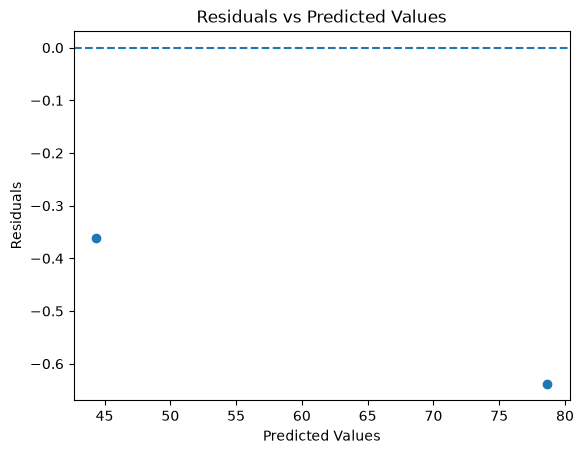

In [9]:
residuals = y_test - y_test_pred

plt.scatter(y_test_pred, residuals)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted Values")
plt.show()


## 10. Mean Absolute Percentage Error

MAPE should be used carefully when actual values are zero or close to zero.


In [10]:
def mape(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

print("MAPE (%):", mape(y_test, y_test_pred))


MAPE (%): 0.8203721565790516


## 11. Five-Fold Cross-Validation


In [11]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

neg_mse_scores = cross_val_score(
    LinearRegression(),
    X,
    y,
    cv=kf,
    scoring="neg_mean_squared_error"
)

rmse_scores = np.sqrt(-neg_mse_scores)

print("Fold RMSE:", rmse_scores)
print("Mean CV RMSE:", rmse_scores.mean())
print("Std CV RMSE:", rmse_scores.std())


Fold RMSE: [0.51867617 0.67185481 0.55901699 1.16963907 0.86964762]
Mean CV RMSE: 0.7577669335731485
Std CV RMSE: 0.23924998176894144


## 12. Cross-Validation With MAE


In [12]:
neg_mae_scores = cross_val_score(
    LinearRegression(),
    X,
    y,
    cv=kf,
    scoring="neg_mean_absolute_error"
)

mae_scores = -neg_mae_scores

print("Fold MAE:", mae_scores)
print("Mean CV MAE:", mae_scores.mean())


Fold MAE: [0.5        0.58333333 0.5        1.16666667 0.71153846]
Mean CV MAE: 0.6923076923076927


## 13. Cross-Validation With $R^2$


In [13]:
r2_scores = cross_val_score(
    LinearRegression(),
    X,
    y,
    cv=kf,
    scoring="r2"
)

print("Fold R2:", r2_scores)
print("Mean CV R2:", r2_scores.mean())


Fold R2: [0.99906912 0.99686535 0.99782986 0.99049961 0.98818302]
Mean CV R2: 0.9944893927798398


## 14. Comparing Two Models


In [14]:
model_a = LinearRegression()
model_b = LinearRegression()

# Model A: one predictor
scores_a = cross_val_score(
    model_a, X, y, cv=kf, scoring="neg_mean_absolute_error"
)

# Model B: add a polynomial feature manually
X_poly = X.copy()
X_poly["study_hours_squared"] = X_poly["study_hours"] ** 2

scores_b = cross_val_score(
    model_b, X_poly, y, cv=kf, scoring="neg_mean_absolute_error"
)

print("Model A mean CV MAE:", (-scores_a).mean())
print("Model B mean CV MAE:", (-scores_b).mean())


Model A mean CV MAE: 0.6923076923076927
Model B mean CV MAE: 0.6956024744816197


## 15. Baseline Model

A simple baseline predicts the training-set mean for every test observation.


In [15]:
baseline_prediction = np.repeat(y_train.mean(), len(y_test))

baseline_rmse = np.sqrt(
    mean_squared_error(y_test, baseline_prediction)
)

print("Baseline RMSE:", baseline_rmse)
print("Regression RMSE:", test_rmse)


Baseline RMSE: 17.00735135169495
Regression RMSE: 0.5186761709134947


## 16. Practice Questions

1. Create your own actual and predicted arrays and calculate MAE, MSE, and RMSE manually.
2. Verify the same metrics with scikit-learn.
3. Explain why RMSE is more sensitive to large errors than MAE.
4. Calculate $R^2$ manually from SSE and SST.
5. Compare training and test RMSE for a regression model.
6. Create a model that is intentionally too complex and inspect the training/test difference.
7. Perform five-fold cross-validation and report mean and standard deviation of RMSE.
8. Compare two regression models using MAE and RMSE.
9. Create a residual plot and describe any visible pattern.
10. Calculate MAPE and explain why zero actual values create a problem.
11. Build a baseline model and compare its test RMSE with a regression model.
12. Explain why repeatedly using the test set for model selection can make the final evaluation optimistic.


## 17. Final Practical Checklist

- Keep training and final test data separate.
- Choose metrics that match the practical cost of errors.
- Report MAE or RMSE when response-unit interpretation is useful.
- Use $R^2$ as a complementary measure rather than the only metric.
- Inspect residuals for systematic patterns.
- Use cross-validation for model comparison and tuning when appropriate.
- Protect the final test set from repeated model-selection decisions.
- Watch for data leakage.
- Compare models on the same evaluation procedure.
